In [3]:
import os
from pathlib import Path
import struct

import jax
# jax.config.update('jax_enable_x64', True)
from jax import numpy as np, tree as jtu, Array, random as jr
from jax.experimental import checkify

import amigo as amg

import dorito as drt

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(['science',  'bright', 'no-latex'])
new_rcParams = {
    'image.cmap': 'inferno',
    'font.family': 'serif',
    'image.origin': 'lower',
    'figure.dpi': 300,
    'font.size': 8,
    'xtick.direction': 'out',
    'ytick.direction': 'out'
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps['inferno']
viridis = mpl.colormaps['viridis']
seismic = mpl.colormaps['seismic']
coolwarm = mpl.colormaps['coolwarm']

inferno.set_bad('k', 0.5)
viridis.set_bad('k', 0.5)
seismic.set_bad('k', 0.5)
coolwarm.set_bad('k', 0.5)


In [4]:
from frito import utils
utils.mas2rad

4.8481368110953594e-09

In [5]:
mas2rad = np.pi / (180.0 * 3600.0 * 1000.0)
master_key              = jr.key(0)
main_data_path          = '_data'
autoencoder_data_path   = os.path.join(main_data_path, 'autoencoder')
main_trained_model_path = os.path.join(autoencoder_data_path, 'trained_models')
main_svd_path           = os.path.join(autoencoder_data_path, 'svd')
training_data_path      = os.path.join(autoencoder_data_path, 'training_data')
emnist_path             = os.path.join(training_data_path, 'emnist.npz')
mnist_path              = os.path.join(training_data_path, 'mnist.npz')
ppd_51_path             = os.path.join(training_data_path, 'fake_intensity_PPDs_51x51.npz')

main_out_path           = '_output'
main_model_struct_path  = 'src/frito/autoencoder/model_structures'

ppd_51x51_data          = np.load(ppd_51_path)
test_51x51_data         = ppd_51x51_data['x_test']
test_51x51_data         = np.clip(test_51x51_data / np.max(test_51x51_data, axis=(1,2), keepdims=True), min=1e-8).astype(np.float64)
test_51x51_image        = test_51x51_data[225]


emnist_data             = np.load(emnist_path)
test_emnist_data        = emnist_data['x_test']
test_emnist_data        = np.clip(test_emnist_data / np.max(test_emnist_data, axis=(1,2), keepdims=True), min=1e-8)
test_emnist_image       = test_emnist_data[420]

disco_HD135344B_path = os.path.join(main_data_path, 'jwst', 'HD135344B', 'disco', 'cal_vis_HD135344B.npy')
disco_PDS70_path = os.path.join(main_data_path, 'jwst', 'PDS70', 'disco', 'bgmask_cal_vis_pds70.npy')

/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Text(0.5, 1.0, 'Example Letter')

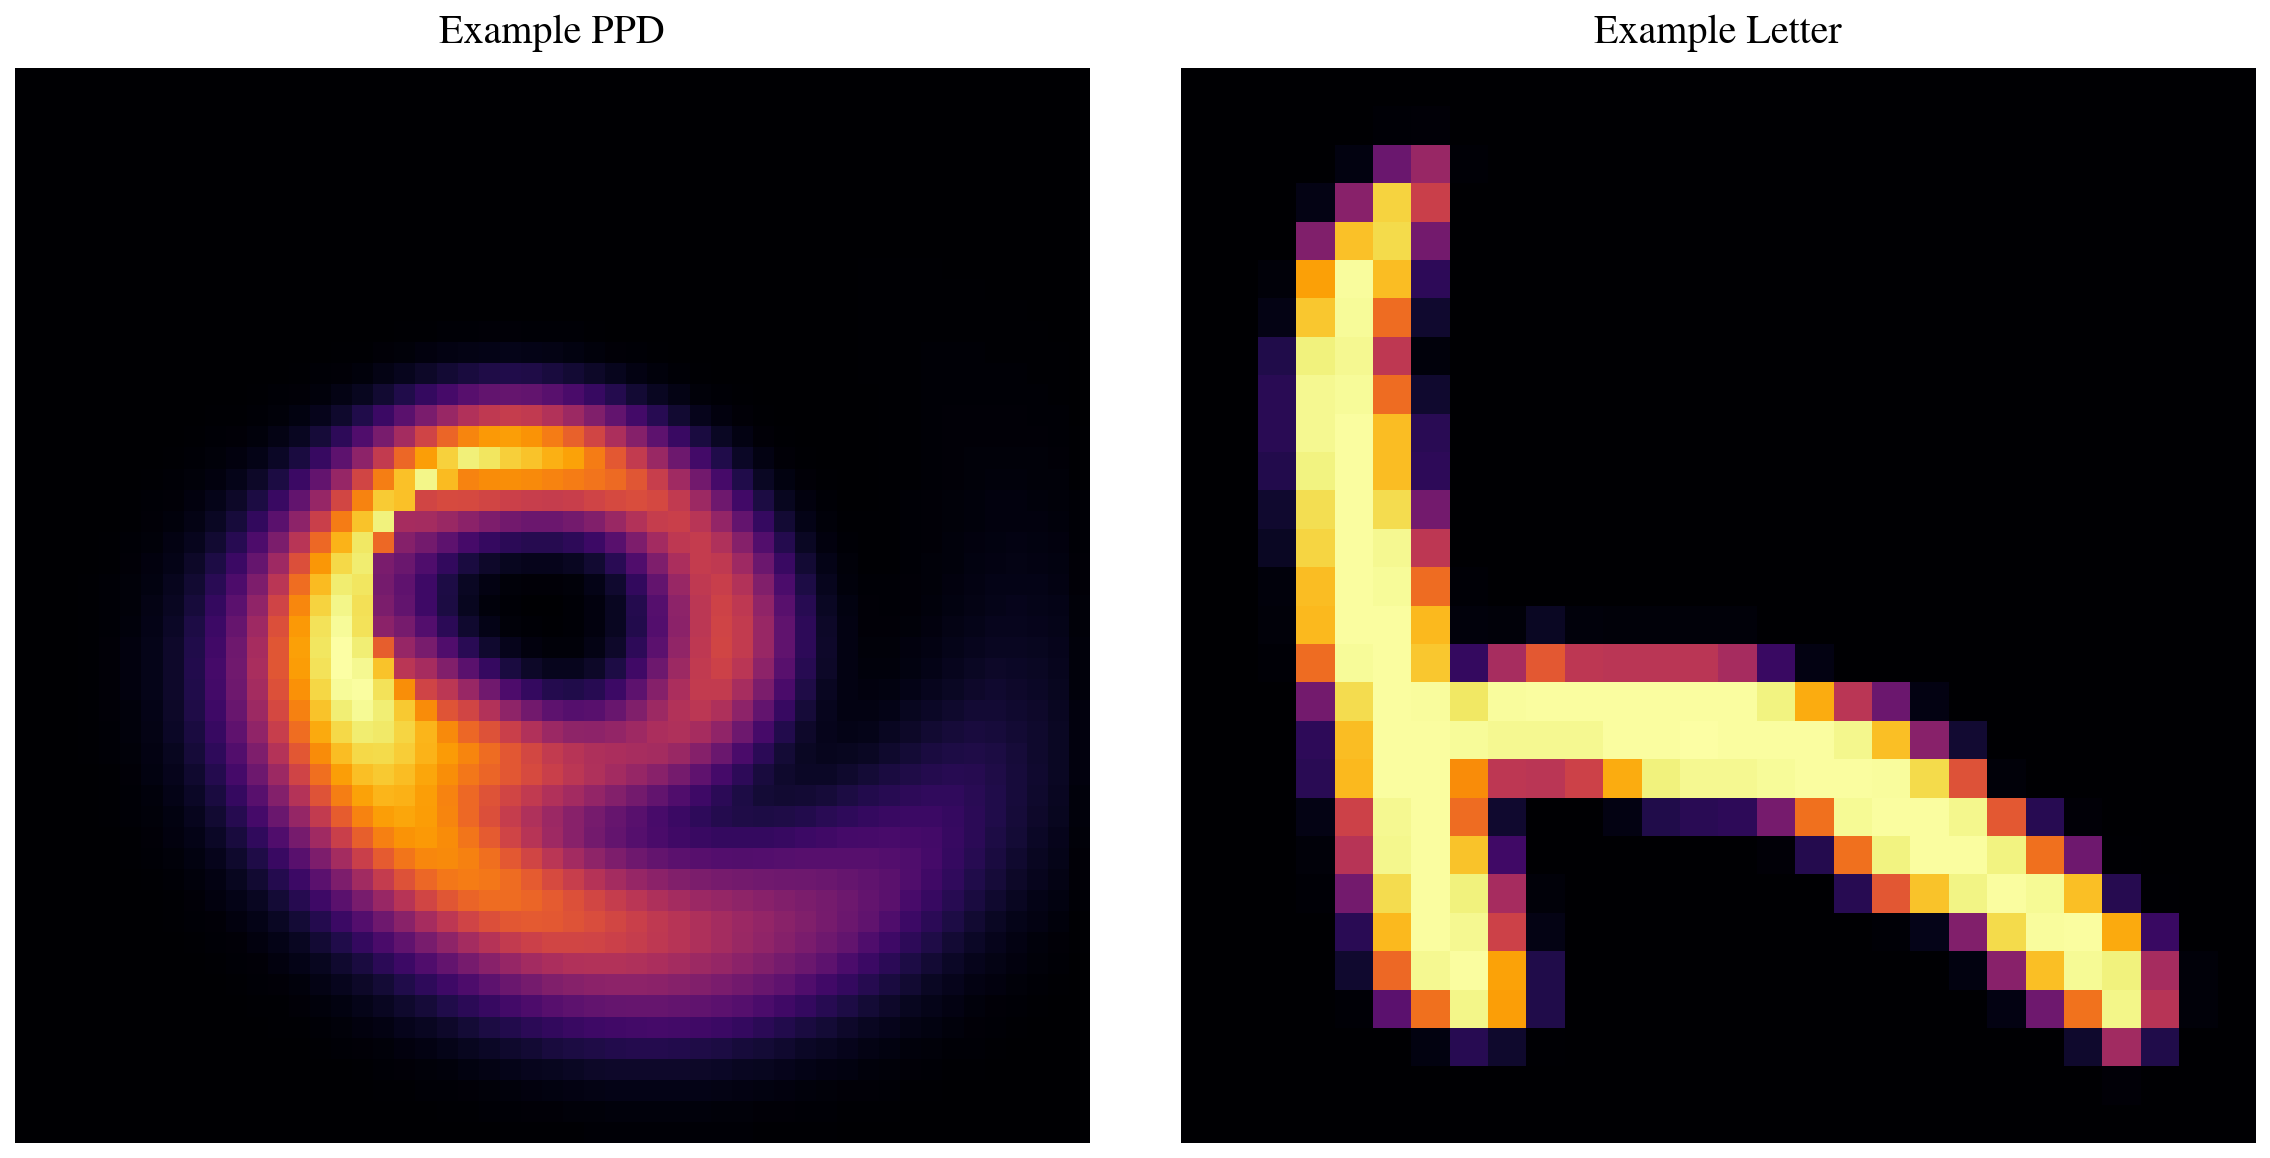

In [6]:
fig, ax = plt.subplots(1,2, figsize=(8,4), layout='tight')
ax[0].imshow(test_51x51_image)
ax[0].set_axis_off()
ax[0].set_title('Example PPD')
ax[1].imshow(test_emnist_image)
ax[1].set_axis_off()
ax[1].set_title('Example Letter')

In [7]:
def load_disco(path: str | Path) -> dict:
    data = np.load(path, allow_pickle=True).item()
    filters = data.keys()
    filter1 = list(filters)[0]
    disco_keys = data[filter1].keys()
    return data, filters, disco_keys
disco, filters, disco_keys = load_disco(disco_HD135344B_path)
disco_1filter = disco['F480M']
u = disco_1filter['u']
v = disco_1filter['v']
wavel = disco_1filter['wavel']

In [8]:
def normalize_image(img: np.ndarray) -> np.ndarray:
    img = np.asarray(img, dtype=np.float64)
    checkify.check(img.ndim == 2, f'Image must be 2-D, got shape {img.shape}')
    s = img.sum()
    checkify.check(s > 0, "Image has non-positive total flux")
    return img / s
# multi_images = jax.vmap(normalize_image)(test_51x51_data[0:10])
norm_PPD = normalize_image(test_51x51_image)
norm_EMNIST = normalize_image(test_emnist_image)

/var/folders/h4/2rx10bmx2h71dyk59bq42frh0000gn/T/ipykernel_77994/1676052115.py:2: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  img = np.asarray(img, dtype=np.float64)


In [9]:
def _image_pixel_grid_rad(n_rows: int, n_cols: int, pscale_mas: float=16.4) -> tuple[np.ndarray, np.ndarray]:
    def half(n: int):
        if n % 2 == 0:
            return n / 2.0
        else:
            return (n - 1.0) / 2.0
    alpha = (np.arange(n_cols) - half(n_cols)) * pscale_mas * mas2rad
    delta = (np.arange(n_rows) - half(n_rows)) * pscale_mas * mas2rad
    return alpha, delta

In [10]:
def image2ComplexVis(img: np.ndarray, u: np.ndarray, v: np.ndarray, wavel: float, pscale_mas: float=16.4) -> np.ndarray:
    checkify.check(img.ndim == 2, f"Image must be 2-D, got shape {img.shape}")

    n_rows, n_cols = img.shape
    alpha, delta = _image_pixel_grid_rad(n_rows, n_cols, pscale_mas)

    wavenum = 2 * np.pi / wavel
    phase_alpha = np.exp(-1j * wavenum * np.outer(u, alpha))
    phase_delta = np.exp(-1j * wavenum * np.outer(v, delta))

    V = np.einsum("ki, ij, kj->k", phase_delta, img, phase_alpha)
    return V

In [11]:
PPD_V = image2ComplexVis(norm_PPD, u, v, wavel)

In [12]:
disco_keys

dict_keys(['u', 'v', 'vis_mat', 'phi_mat', 'K_vis_mat', 'K_phi_mat', 'parang', 'wavel', 'O_vis', 'O_phi', 'O_vis_cov', 'O_phi_cov', 'O_vis_mat', 'O_phi_mat', 'O_vis_eigv', 'O_phi_eigv', 'disco_vis_mat', 'disco_phi_mat', 'K_vis', 'K_vis_cov', 'K_phi', 'K_phi_cov', 'vis', 'vis_cov', 'phi', 'phi_cov'])

In [13]:
def observables_from_image(img: np.ndarray, filter_block: dict, pscale_mas: float = 16.4, flux_scale: float=1.0):
    u = filter_block['u']
    v = filter_block['v']
    wavel = float(filter_block['wavel'])

    img = np.asarray(img, dtype=np.float64) * float(flux_scale)

    V = image2ComplexVis(img, u, v, wavel, pscale_mas)

    amplitudes = np.abs(V)                  # (1300,)
    phases = np.angle(V)                    # (1300,)

    vis_mat = filter_block['vis_mat']       # (420, 1300)
    phi_mat = filter_block['phi_mat']       # (420, 1300)
    vis = vis_mat @ amplitudes              # (420,)
    phi = phi_mat @ phases                  # (420,)

    K_vis_mat = filter_block["K_vis_mat"]   # (349, 420)
    K_phi_mat = filter_block["K_phi_mat"]   # (349, 420)
    K_vis = K_vis_mat @ vis                 # (349,)
    K_phi = K_phi_mat @ phi                 # (349,)

    O_vis_mat = filter_block["O_vis_mat"]   # (349, 349)
    O_phi_mat = filter_block["O_phi_mat"]   # (349, 349)
    O_vis = O_vis_mat @ K_vis               # (349,)     
    O_phi = O_phi_mat @ K_phi               # (349,)
    
    return dict(vis=vis, phi=phi, K_vis=K_vis, K_phi=K_phi, O_vis=O_vis, O_phi=O_phi)
test_obs = observables_from_image(norm_PPD, disco_1filter)

/var/folders/h4/2rx10bmx2h71dyk59bq42frh0000gn/T/ipykernel_77994/271570999.py:6: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  img = np.asarray(img, dtype=np.float64) * float(flux_scale)


In [14]:
def _draw_correlated_noise(cov: np.ndarray, key: Array=jr.key(0)) -> np.ndarray:
    C = 0.5 * (cov + cov.T)
    w, V = np.linalg.eigh(C)
    w_clipped = np.clip(w, 0.0, None)
    L = V * np.sqrt(w_clipped)
    z = jr.normal(key=key, shape=C.shape[0])
    return L @ z
test_noise = _draw_correlated_noise(disco_1filter['vis_cov'])

In [15]:
def inject_image(disco_template: dict, img: np.ndarray, pscale_mas: float=16.4, flux_scale: float=1.0, add_noise: bool=True, scale_noise_w_flux: bool=False, key: Array=jr.key(0)):
    norm_img = normalize_image(img)
    cov_factor = 1.0 / (flux_scale ** 2)
    
    if scale_noise_w_flux and flux_scale == 1.0:
        print("Scaling noise with flux, but the flux scale is 1.0, so no scaling happens")
    elif scale_noise_w_flux and flux_scale != 1.0:
        print(f'Scaling noise by {cov_factor:.3f}')

    cov_keys = ["vis_cov", "phi_cov", "K_vis_cov", "K_phi_cov", "O_vis_cov", "O_phi_cov"]
    eigv_keys = ["O_vis_eigv", "O_phi_eigv"]
    
    out = {}
    for filter, disco_filter in disco_template.items():
        new_disco_filter = dict(disco_filter)
        observables = observables_from_image(norm_img, disco_filter, pscale_mas, flux_scale)
        new_disco_filter.update(observables)

        if scale_noise_w_flux and cov_factor != 1.0:
            for ck in cov_keys:
                if ck in new_disco_filter:
                    new_disco_filter[ck] = new_disco_filter[ck] * cov_factor
            for ek in eigv_keys:
                if ek in new_disco_filter:
                    new_disco_filter[ek] = new_disco_filter[ek] * cov_factor
        if add_noise:
            for disco_key, disco_cov_key in [
                ("vis", "vis_cov"), ("phi", "phi_cov"),
                ("K_vis", "K_vis_cov"), ("K_phi", "K_phi_cov"),
                ("O_vis", "O_vis_cov"), ("O_phi", "O_phi_cov")
            ]:
                cov = new_disco_filter[disco_cov_key]
                noise = _draw_correlated_noise(cov, key)
                new_disco_filter[disco_key] = new_disco_filter[disco_key] + noise
            
        out[filter] = new_disco_filter
    return out
